## 2D CSA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import bisect

In [2]:
np.random.seed(0)

### Data Simulation 
simulating the data according to different classes

In [3]:
def simulate_class_data(n_per_class):
    """
    Simulates 4 scenarios of class data
        - Class A: P1 is good and P2 is bad
        - Class B: P1 is bad and P2 is good 
        - Class C: Both P1 and P2 are good
        - Class D: Both P1 and P2 are bad
        - Class E: Mixed scenario - correlated scores

    scores = 1-p (so 0.1 is good and 0.8 is bad)
    """

    # Class A: P1 is good (0.1) and P2 is bad (0.7)
    A = np.abs(np.random.multivariate_normal([0.1, 0.7], [[0.01, 0], [0, 0.01]], n_per_class))

    # Class B: P1 is bad (0.7) and P2 is good (0.1)
    B = np.abs(np.random.multivariate_normal([0.7, 0.1], [[0.01, 0], [0, 0.01]], n_per_class))  

    # Class C: Both P1 and P2 are good (0.1)
    C = np.abs(np.random.multivariate_normal([0.1, 0.1], [[0.01, 0], [0, 0.01]], n_per_class))  

    # Class D: Both P1 and P2 are bad (0.7)
    D = np.abs(np.random.multivariate_normal([0.7, 0.7], [[0.01, 0], [0, 0.01]], n_per_class))  

    # Combining all the classes into one dataset
    all_scores = np.vstack((A, B, C, D))
    all_scores = np.clip(all_scores, 0, 1)  # Clipping to make sure that all scores are between 0 and 1

    # Returning the scores and labels
    labels = np.array(['A']*100 + ['B']*100 + ['C']*100 + ['D']*100)
    return all_scores, labels

### Phage-Wise Data Splitting 

In [4]:
def split_calibration_data(scores, split_ratio):
    """
    Splits the calibration data into two sets based on the split ratio.
    """
    n = len(scores)
    indices = np.arange(n)
    np.random.shuffle(indices)

    limit = int(n * split_ratio)     # Number of samples for the shape set
    shape_set = scores[indices[:limit]]
    size_set = scores[indices[limit:]]
    return shape_set, size_set

### Discovering the Shape

**$\pi / 2$ --> $2 \pi$???** 

In [5]:
def shape_discovery(shape_set_scores, alpha, M):
 
    # Directions (Angles 0 to 90 degrees)
    angles = np.linspace(0, np.pi/2, M)
    u_directions = np.vstack([np.cos(angles), np.sin(angles)]).T

    # Projecting the scores from the 'shape' sets onto the directions
    projections = shape_set_scores @ u_directions.T
    
    # We are searcging for the largest beta such that the intersection of half-planes defined by the quantiles has coverage >= 1-alpha
    # We will search from small beta (wide region) to large beta (tight region)
    beta_candidates = np.linspace(alpha/M, alpha, 500)
    
    beta_star = alpha/M     # Default to conservative Bonferroni
    q_tilde = np.quantile(projections, 1 - beta_star, axis=0)

    for beta in beta_candidates:
        q_beta = np.quantile(projections, 1 - beta, axis=0)
        
        # Intersection of Half-Planes
        inside = np.all(projections <= q_beta, axis=1)
        coverage = np.mean(inside)      # Proportion of samples inside the intersection region defined by q_beta
        
        if coverage >= 1 - alpha:
            beta_star = beta
            q_tilde = q_beta
        else:
            break 

    return u_directions, q_tilde, beta_star

### Scaling

In [6]:
def size_scaling(size_set_scores, u_directions, q_tilde, alpha):
    """
    Calculates t_hat using the Finite-Sample Rank Lemma.
    """

    # Projecting the scores from the 'size' sets
    projections = size_set_scores @ u_directions.T
    
    # Calculating the non-conformity scores (Maximum Ratio)
    # tau tells us how much we must scale the shape to include the point
    ratios = projections / (q_tilde + 1e-12)
    tau_scores = np.max(ratios, axis=1)

    # Finite-Sample Quantile Calculation
    # According to the Quantile Lemma: t = sorted_tau[ceil((n+1)(1-alpha))]
    n2 = len(tau_scores)
    sorted_tau = np.sort(tau_scores)
    
    # Calculating the exact index for the quantile
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    
    # Safety clip for small datasets
    idx = np.clip(idx, 0, n2 - 1)
    t_hat = sorted_tau[idx]

    return t_hat, tau_scores

## Testing Function 
tests for a new phage

In [7]:
def test_new_phage(new_score , u_directions, q_tilde, t_hat):
    """
    Tests a new phage score against the discovered shape and size - determines if it is accepted or rejected
    """
    # Projecting the new score onto the directions
    new_projection = new_score @ u_directions.T
    
    # calculating the max ratio for the new score
    new_ratio = np.max(new_projection / (q_tilde + 1e-12))

    # Checking if the projection is within the scaled shape
    is_accepted = new_ratio <= t_hat    
    
    return is_accepted, new_ratio

### Visualizing

In [8]:
def plot_csa_steps(scores, shape_set_scores, size_set_scores, u_directions, q_tilde, t_hat, alpha):
    fig,axs = plt.subplots(1,3, figsize=(18,5))

    # Plot 1 - the directions
    axs[0].scatter(shape_set_scores[:, 0], shape_set_scores[:, 1], color='blue', alpha=0.3, label='Shape Set Scores')


    for u in u_directions[:: 10]:    # Plotting every 10th direction for clarity
        axs[0].quiver(0, 0, u[0], u[1], scale = 3, color='red', alpha=0.5)

    axs[0].set_title('Directional Projections (u)')
    axs[0].set_xlabel('Model 1 Error Score')
    axs[0].set_ylabel('Model 2 Error Score')
    axs[0].legend()
    # axs[0].set_xlim(0, 0.5)
    # axs[0].set_ylim(0, 0.5) 


    # Plot 2 - half space intersection (the shape)
    x_range = np.linspace(0, 1, 100)
    y_range = np.linspace(0, 1, 100)
    X, Y = np.meshgrid(x_range, y_range)
    grid = np.vstack([X.ravel(), Y.ravel()]).T

    # Checking which points in the grid are inside the intersection of half spaces defined by q_tilde
    inside_shape = np.all((u_directions @ grid.T).T <= q_tilde, axis=1).reshape(X.shape)

    axs[1].scatter(shape_set_scores[:, 0], shape_set_scores[:, 1], color='blue', alpha=0.3, label='Shape Set Scores')
    axs[1].contourf(X, Y, inside_shape, levels=[0.5,1], colors='blue', alpha=0.3)
    axs[1].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linewidths=2)
    axs[1].set_title('Intersection of Half Spaces (Quantile Envelope)')
    axs[1].set_xlabel('Model 1 Error Score')
    axs[1].set_ylabel('Model 2 Error Score')
    axs[1].legend()


    # Plot 3 - size scaling (zooming in or out) to get the final region
    q_final = q_tilde * t_hat  # Final quantiles after scaling
    inside_final_shape = np.all((u_directions @ grid.T).T <= q_final, axis=1).reshape(X.shape)

    axs[2].scatter(size_set_scores[:, 0], size_set_scores[:, 1], color='green', alpha=0.3, label='Size Set Scores')
    axs[2].scatter(shape_set_scores[:, 0], shape_set_scores[:, 1], color='blue', alpha=0.3, label='Shape Set Scores')

    # plotting the original shape dashed and final shape with a solid line
    axs[2].contour(X, Y, inside_shape, levels=[0.5], colors='blue', linestyles='--')
    axs[2].contourf(X, Y, inside_final_shape, levels=[0.5,1], colors = 'green', alpha=0.3)
    axs[2].contour(X, Y, inside_final_shape, levels=[0.5], colors='green', linewidths=2)
    axs[2].set_title(f"Final Calibrated Region (Scaled Quantile Envelope)(t = {t_hat:.2f})")
    axs[2].set_xlabel('Model 1 Error Score')
    axs[2].set_ylabel('Model 2 Error Score')
    axs[2].legend()
    plt.tight_layout()
    plt.show()

execution

New phage score: [0.12 0.68]
Calculated ratio for the new score: 0.91. Must be <= t_hat (1.00) for acceptance
Is the new phage accepted in the 90% confidence set? True


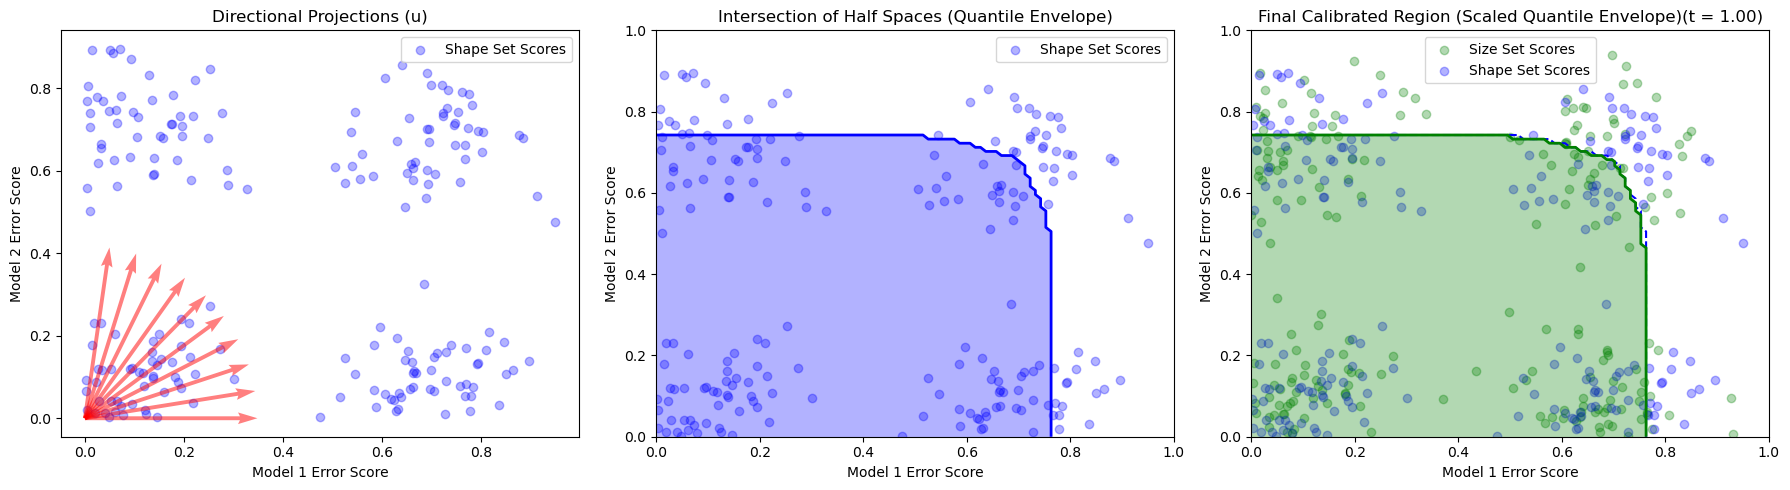

In [9]:
alpha = 0.3  # 90% coverage guarantee
M = 100  # Number of directions for half spaces

# simulating the data 
raw_scores, labels = simulate_class_data(n_per_class=100)

# splitting the data into shape and size sets
S1, S2 = split_calibration_data(raw_scores, split_ratio=0.5)

# finding the shape (geometry) of the acceptance region using half spaces
u_directions, q_tilde, beta_star = shape_discovery(S1, alpha, M)

# finding the scaling factor 't' to guarantee the 1-alpha coverage probability
t_hat, tau_scores = size_scaling(S2, u_directions, q_tilde, alpha)

# TESTING
# creating a new phage score to test from class A (good P1 and bad P2)
new_score = np.array([0.12, 0.68])
accepted, ratio = test_new_phage(new_score, u_directions, q_tilde, t_hat)

print(f"New phage score: {new_score}")
print(f"Calculated ratio for the new score: {ratio:.2f}. Must be <= t_hat ({t_hat:.2f}) for acceptance")
print(f"Is the new phage accepted in the 90% confidence set? {accepted}")

# plotting the steps of the CSA method
plot_csa_steps(raw_scores, S1, S2, u_directions, q_tilde, t_hat, alpha)